# Geumho River Water Quality Monitoring

This notebook explores daily water-quality measurements from Korea's national water quality monitoring network, focusing on **Total Phosphorus (T-P)** — a key indicator of nutrient pollution and a driver of algal blooms in rivers and reservoirs.

The analysis has two parts:
1. A quick look at one station (**Osan Stream 2**) using only the 2025 data, to build and test the cleaning pipeline.
2. A **10-year trend (2016–2025)** for a station on the Geumho River (**금호강3**, near Daegu/Gyeongsan).

## Setup
Load `pandas`, used throughout for reading the Excel files and manipulating the data.

In [3]:
import pandas as pd
print("pandas is ready")

pandas is ready


## Load the raw data
The source files are large (tens of thousands of rows, 65+ columns, hundreds of stations nationwide), so first only `nrows=5` is read to check column names and shape before working with the full file.

In [4]:
df = pd.read_excel("../data/전국수질측정자료_2025년_1~12월_일자료.xlsx", nrows=5)
df.head()


,No,연도,월,조사회차,채수 일자,채수시각,수계 명,중권역 명,측정소 명,분류번호,...,셀레늄(Se),부유물질(SS),트리클로로에틸렌(TCE),총대장균군,수온,총질소(T-N),총유기탄소(TOC),총인(T-P),투명도,아연(Zn)
0,1,2025,1,1회차,2025.01.20,12:00,한강,남한강상류,골지천1,1001A13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2025,1,1회차,2025.01.06,11:00,한강,남한강상류,골지천2,1001A15,...,NaN,2.0,NaN,370.0,4.9,2.525,0.8,0.007,NaN,NaN
2,3,2025,1,1회차,2025.01.21,11:10,한강,남한강상류,동강1,1001A73,...,NaN,0.5,NaN,NaN,3.0,3.033,0.4,0.008,NaN,NaN
3,4,2025,1,1회차,2025.01.23,12:00,한강,남한강상류,오대천2,1001A38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2025,1,1회차,2025.01.20,14:00,한강,남한강상류,송현천,1001A23,...,NaN,6.7,NaN,NaN,1.2,8.426,0.8,0.045,NaN,NaN


## Filter for a single station (2025 only)
The full 2025 file is read, keeping only three columns: station name, sample date, and Total Phosphorus. The data is filtered to a single station, **오산천2 (Osan Stream 2)**, to keep the first pass small.

In [5]:
df_full = pd.read_excel("../data/전국수질측정자료_2025년_1~12월_일자료.xlsx", usecols=[" 측정소 명", " 채수 일자", "총인(T-P)"])
station = df_full[df_full[" 측정소 명"] == "오산천2"]
station


,채수 일자,측정소 명,총인(T-P)
337,2025.01.21,오산천2,0.183
568,2025.01.06,오산천2,NaN
569,2025.01.14,오산천2,0.075
570,2025.01.20,오산천2,NaN
571,2025.01.27,오산천2,NaN
...,...,...,...
21542,2025.12.02,오산천2,0.038
21543,2025.12.10,오산천2,0.048
21544,2025.12.15,오산천2,NaN
21545,2025.12.22,오산천2,NaN


## Clean the data
- Convert T-P to numeric (non-numeric entries become `NaN`).
- Drop rows with missing T-P values.
- Convert the date column to `datetime` and sort chronologically.

In [6]:
station = station.copy()
station["총인(T-P)"] = pd.to_numeric(station["총인(T-P)"], errors="coerce")
station_clean = station.dropna(subset=["총인(T-P)"]).copy()
station_clean[" 채수 일자"] = pd.to_datetime(station_clean[" 채수 일자"], format="%Y.%m.%d")
station_clean = station_clean.sort_values(" 채수 일자")
station_clean


,채수 일자,측정소 명,총인(T-P)
569,2025-01-14,오산천2,0.075
337,2025-01-21,오산천2,0.183
1749,2025-02-11,오산천2,0.085
1750,2025-02-24,오산천2,0.071
2003,2025-02-25,오산천2,0.073
...,...,...,...
19627,2025-11-27,오산천2,0.057
21256,2025-12-01,오산천2,0.077
21542,2025-12-02,오산천2,0.038
21257,2025-12-08,오산천2,0.057


## Summary statistics
A statistical summary (count, mean, std, quartiles) of Total Phosphorus at this station in 2025.

In [7]:
station_clean["총인(T-P)"].describe()


count    77.000000
mean      0.110052
std       0.060159
min       0.035000
25%       0.070000
50%       0.098000
75%       0.126000
max       0.378000
Name: 총인(T-P), dtype: float64

## Visualize T-P over 2025
Time series plot of Total Phosphorus at Osan Stream 2 across 2025.

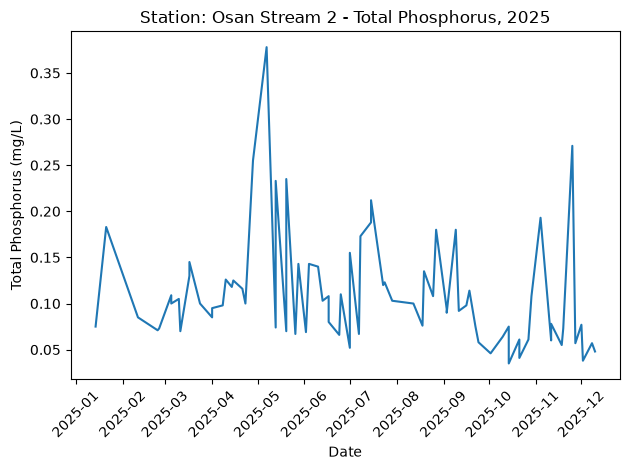

In [8]:
import matplotlib.pyplot as plt

plt.plot(station_clean[" 채수 일자"], station_clean["총인(T-P)"])
plt.xlabel("Date")
plt.ylabel("Total Phosphorus (mg/L)")
plt.title("Station: Osan Stream 2 - Total Phosphorus, 2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




## Extend to a 10-year trend on the Geumho River
The rest of the notebook repeats the same pipeline, combining **five Excel files** (2016–2025) for station **금호강3** on the Geumho River.

In [9]:
files = [
    "../data/전국수질측정자료_2016년_2021년_일자료.xlsx",
    "../data/전국수질측정자료_2022년_일자료.xlsx",
    "../data/전국수질측정자료_2023년_1~12월_일자료.xlsx",
    "../data/전국수질측정자료_2024년_1~12월_일자료.xlsx",
    "../data/전국수질측정자료_2025년_1~12월_일자료.xlsx",
]


## Load and filter all five files
Each file is read, filtered to station 금호강3, and collected into a list, then concatenated into one DataFrame. The printed row counts are a sanity check that data exists for every period.

In [10]:
all_years = []
for f in files:
    df_year = pd.read_excel(f, usecols=[" 측정소 명", " 채수 일자", "총인(T-P)"])
    station_year = df_year[df_year[" 측정소 명"] == "금호강3"]
    all_years.append(station_year)
    print(f, "->", len(station_year), "rows")

station_all = pd.concat(all_years)
station_all



../data/전국수질측정자료_2016년_2021년_일자료.xlsx -> 72 rows
../data/전국수질측정자료_2022년_일자료.xlsx -> 12 rows
../data/전국수질측정자료_2023년_1~12월_일자료.xlsx -> 12 rows
../data/전국수질측정자료_2024년_1~12월_일자료.xlsx -> 12 rows
../data/전국수질측정자료_2025년_1~12월_일자료.xlsx -> 12 rows


,채수 일자,측정소 명,총인(T-P)
385,2016.01.08,금호강3,0.020
2284,2016.02.05,금호강3,0.043
4054,2016.03.10,금호강3,0.032
6207,2016.04.08,금호강3,0.107
8397,2016.05.13,금호강3,0.092
...,...,...,...
14070,2025.08.01,금호강3,0.05
16069,2025.09.04,금호강3,0.128
18046,2025.10.17,금호강3,0.236
19874,2025.11.06,금호강3,0.016


## Clean the combined 10-year data
Same cleaning steps as before, applied across all ~10 years of records.

In [11]:
station_all = station_all.copy()
station_all["총인(T-P)"] = pd.to_numeric(station_all["총인(T-P)"], errors="coerce")
station_all_clean = station_all.dropna(subset=["총인(T-P)"]).copy()
station_all_clean[" 채수 일자"] = pd.to_datetime(station_all_clean[" 채수 일자"], format="%Y.%m.%d")
station_all_clean = station_all_clean.sort_values(" 채수 일자")
station_all_clean


,채수 일자,측정소 명,총인(T-P)
385,2016-01-08,금호강3,0.020
2284,2016-02-05,금호강3,0.043
4054,2016-03-10,금호강3,0.032
6207,2016-04-08,금호강3,0.107
8397,2016-05-13,금호강3,0.092
...,...,...,...
14070,2025-08-01,금호강3,0.050
16069,2025-09-04,금호강3,0.128
18046,2025-10-17,금호강3,0.236
19874,2025-11-06,금호강3,0.016


## Visualize the 10-year trend
Total Phosphorus at 금호강3 from 2016 to 2025, showing the seasonal/annual fluctuation pattern.

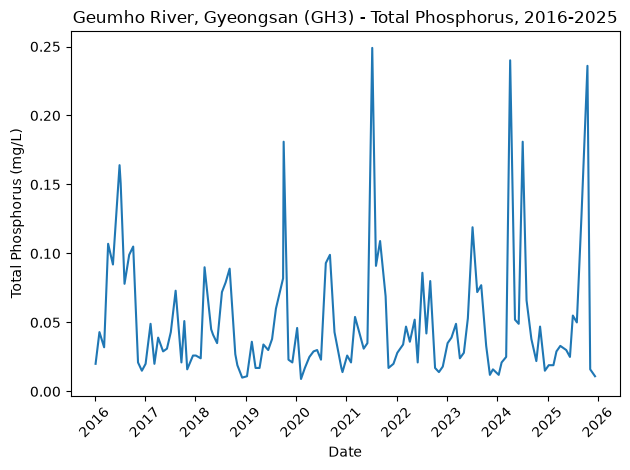

In [12]:
plt.plot(station_all_clean[" 채수 일자"], station_all_clean["총인(T-P)"])
plt.xlabel("Date")
plt.ylabel("Total Phosphorus (mg/L)")
plt.title("Geumho River, Gyeongsan (GH3) - Total Phosphorus, 2016-2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Yearly averages
Grouping by year to see the longer-term trend beyond daily noise.

In [13]:
station_all_clean["year"] = station_all_clean[" 채수 일자"].dt.year
yearly_avg = station_all_clean.groupby("year")["총인(T-P)"].mean()
yearly_avg



year
2016    0.077250
2017    0.034833
2018    0.046417
2019    0.045833
2020    0.037083
2021    0.063667
2022    0.039583
2023    0.046417
2024    0.064000
2025    0.054250
Name: 총인(T-P), dtype: float64

## Yearly average, as a bar chart
Yearly averages compared side by side.

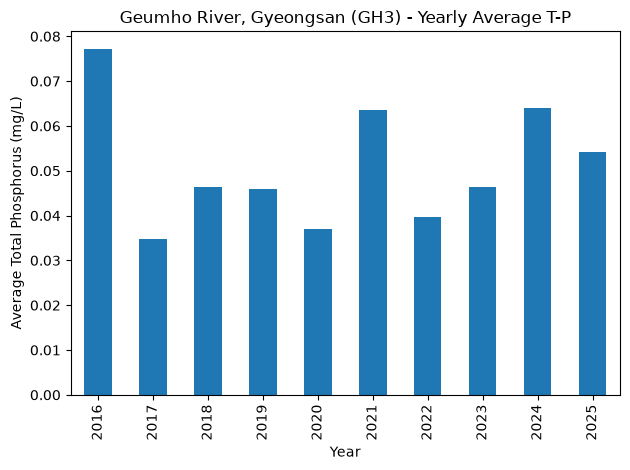

In [14]:
yearly_avg.plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Average Total Phosphorus (mg/L)")
plt.title("Geumho River, Gyeongsan (GH3) - Yearly Average T-P")
plt.tight_layout()
plt.show()
